# MMYC 100 Miler – Course & Route Plotter

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy.interpolate import splprep, splev

from scipy.integrate import solve_bvp

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

In [34]:
# ── Race marks: (lon, lat) — NOTE: cartopy wants lon first ──────────────────
MARKS = {
    "Start/Finish\n(Menominee)": (-87.614, 45.108),
    "Green Island":              (-87.495, 44.990),
    "Fish Creek Buoy":           (-87.245, 45.135),
    "Strawberry Ch. S":          (-87.260, 45.180),
    "Strawberry Ch. N":          (-87.270, 45.215),
    "Chambers Island":           (-87.375, 45.200),
}

# Official course sequence (lon, lat)
OFFICIAL = [
    (-87.614, 45.108),   # Start
    (-87.495, 44.990),   # Green Island
    (-87.245, 45.135),   # Fish Creek
    (-87.260, 45.180),   # Strawberry S
    (-87.270, 45.215),   # Strawberry N
    (-87.375, 45.200),   # Chambers Island
    (-87.614, 45.108),   # Finish
]

# ── Islands / obstacles: (lon, lat, label, radius_deg_approx) ───────────────
OBSTACLES = [
    (-87.357, 45.184, "Chambers Island", 0.035)
    # (-87.370, 45.162, "Horseshoe\nIsland",    0.012),
    # (-87.268, 45.196, "Strawberry\nIslands",  0.018),
    # (-87.495, 44.990, "Green Island",         0.010),
    # (-87.340, 45.215, "Hat Island",           0.008),
    # (-87.290, 45.175, "Nicolet Bay\nShoals",  0.015),
]

# ── Map extent: [lon_min, lon_max, lat_min, lat_max] ────────────────────────
EXTENT = [-87.80, -87.10, 44.88, 45.35]

In [35]:
def smooth_route(waypoints, n=400):
    """Fit a cubic spline through (lon, lat) waypoints."""
    lons = np.array([p[0] for p in waypoints])
    lats = np.array([p[1] for p in waypoints])
    k = min(3, len(waypoints) - 1)
    tck, _ = splprep([lons, lats], s=0, k=k)
    u = np.linspace(0, 1, n)
    lons_s, lats_s = splev(u, tck)
    return list(zip(lons_s, lats_s))

In [36]:
PLATE = ccrs.PlateCarree()


def add_basemap_features(ax):
    """Add land, water, and coastline features to a cartopy axis."""
    ax.add_feature(cfeature.OCEAN.with_scale('10m'),      facecolor='#c8ddf0', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('10m'),       facecolor='#e8e4d9', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale('10m'),      facecolor='#c8ddf0', zorder=1)
    ax.add_feature(cfeature.RIVERS.with_scale('10m'),     edgecolor='#a0bcd0', linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'),  edgecolor='#6a8fa8', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'),    edgecolor='#aaaaaa', linewidth=0.5, linestyle=':', zorder=3)
    ax.add_feature(cfeature.STATES.with_scale('10m'),     edgecolor='#bbbbbb', linewidth=0.4, linestyle='--', zorder=3)


def draw_course(ax, waypoints, color='#222222', lw=1.6,
                linestyle='--', label='Official course', zorder=5):
    lons = [p[0] for p in waypoints]
    lats = [p[1] for p in waypoints]
    ax.plot(lons, lats, linestyle=linestyle, color=color,
            linewidth=lw, transform=PLATE, zorder=zorder, label=label)


def draw_route(ax, route, color, label, lw=2.2, zorder=6):
    lons = [p[0] for p in route]
    lats = [p[1] for p in route]
    ax.plot(lons, lats, color=color, linewidth=lw,
            transform=PLATE, zorder=zorder, label=label, alpha=0.88)
    # Direction arrow at ~60% along the route
    mid = int(len(route) * 0.6)
    ax.annotate('', xy=(lons[mid+3], lats[mid+3]),
                xytext=(lons[mid], lats[mid]),
                xycoords=PLATE._as_mpl_transform(ax),
                textcoords=PLATE._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8),
                zorder=zorder+1)


def draw_marks(ax, marks, zorder=10):
    for i, (name, (lon, lat)) in enumerate(marks.items(), start=1):
        is_start = i == 1
        color = '#111111' if is_start else '#cc2200'
        marker = 's' if is_start else 'o'
        ax.plot(lon, lat, marker=marker, color=color, markersize=9 if is_start else 8,
                markeredgecolor='white', markeredgewidth=1.2,
                transform=PLATE, zorder=zorder)
        # Number badge
        ax.text(lon, lat, str(i), color='white', fontsize=5.5, fontweight='bold',
                ha='center', va='center', transform=PLATE, zorder=zorder+1)
        # Label — nudge to avoid overlap
        nudge = {1: (0.010, 0.006), 2: (-0.015, -0.012),
                 3: (0.010, 0.006), 4: (0.012, -0.005),
                 5: (0.012, 0.005), 6: (-0.005, 0.010)}
        dx, dy = nudge.get(i, (0.008, 0.006))
        ax.text(lon + dx, lat + dy, name,
                fontsize=6.5, color='#111111', transform=PLATE,
                zorder=zorder+1, ha='left',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])


def draw_obstacles(ax, obstacles, zorder=4):
    for lon, lat, label, r in obstacles:
        # Filled circle for island body
        circ = mpatches.Ellipse((lon, lat), width=r*1.4, height=r,
                                 facecolor='#c8b89a', edgecolor='#8a6a40',
                                 linewidth=1.0, transform=PLATE, zorder=zorder,
                                 alpha=0.85)
        ax.add_patch(circ)
        # Dashed exclusion ring
        ring = mpatches.Ellipse((lon, lat), width=(r+0.008)*1.4, height=r+0.008,
                                 facecolor='none', edgecolor='#e6550d',
                                 linewidth=0.8, linestyle=':', transform=PLATE,
                                 zorder=zorder+1, alpha=0.7)
        ax.add_patch(ring)
        ax.text(lon, lat - r - 0.006, label, fontsize=5.5,
                color='#7f2704', ha='center', transform=PLATE, zorder=zorder+2,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])


def add_legend(ax, extra_handles=None):
    handles = [
        Line2D([0],[0], color='#222', lw=1.6, linestyle='--', label='Official course'),
        mpatches.Patch(facecolor='#c8b89a', edgecolor='#8a6a40', label='Island / shoal'),
        mpatches.Patch(facecolor='none', edgecolor='#e6550d',
                       linestyle=':', label='Exclusion zone'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#cc2200',
               markeredgecolor='white', markersize=8, label='Race mark'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#111',
               markeredgecolor='white', markersize=8, label='Start / Finish'),
    ]
    if extra_handles:
        handles += extra_handles
    ax.legend(handles=handles, loc='lower right', fontsize=6.5,
              framealpha=0.92, edgecolor='#cccccc', fancybox=False)


def add_scalebar(ax, lon0, lat0, length_nm=10):
    """Rough scale bar — 1 nm ≈ 1/60 degree latitude."""
    deg = length_nm / 60.0
    ax.plot([lon0, lon0 + deg], [lat0, lat0], 'k-', lw=3, transform=PLATE, zorder=20)
    ax.text(lon0 + deg/2, lat0 + 0.004, f'{length_nm} nm',
            ha='center', fontsize=6, transform=PLATE, zorder=20)

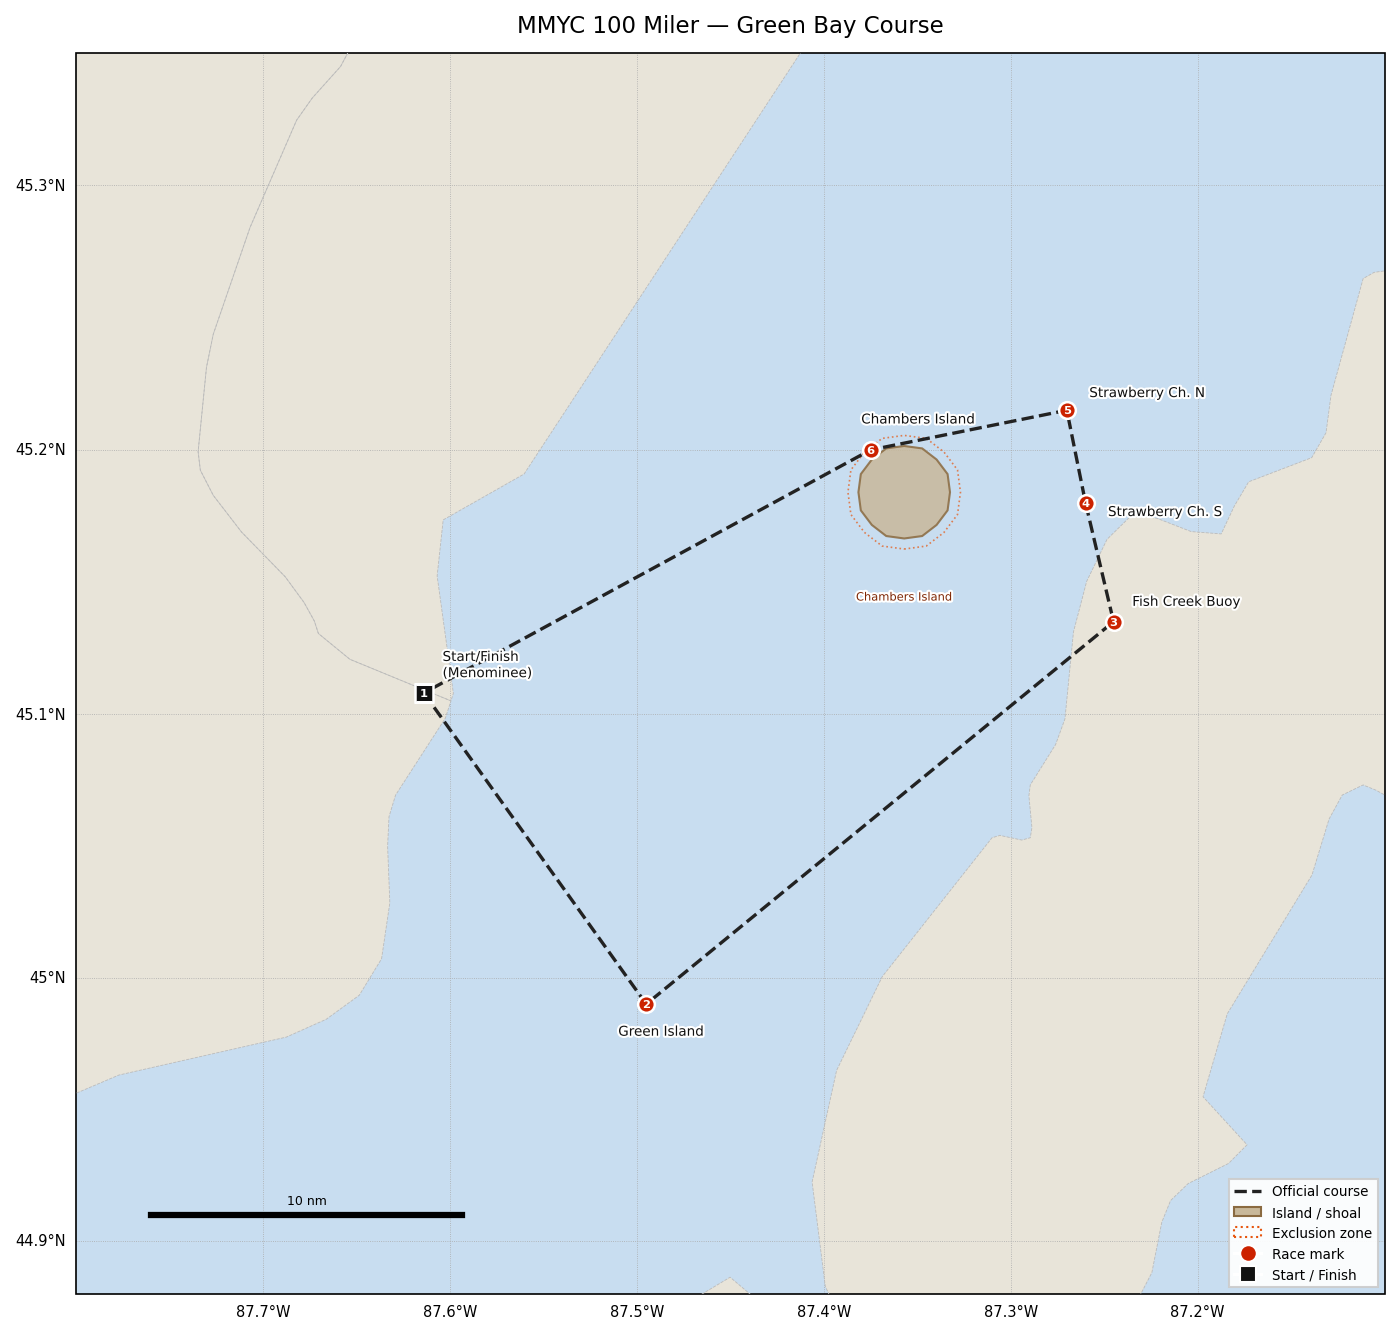

In [37]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

ax.set_extent(EXTENT, crs=PLATE)
add_basemap_features(ax)

draw_obstacles(ax, OBSTACLES)
draw_course(ax, OFFICIAL, label='Official course')
draw_marks(ax, MARKS)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='#aaaaaa',
                  linestyle=':', x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7}
gl.ylabel_style = {'size': 7}

add_scalebar(ax, -87.76, 44.91, length_nm=10)
add_legend(ax)

ax.set_title('MMYC 100 Miler — Green Bay Course', fontsize=11, pad=10)

plt.tight_layout()
# plt.savefig('mmyc_100_miler_full.png', dpi=200, bbox_inches='tight')
plt.show()

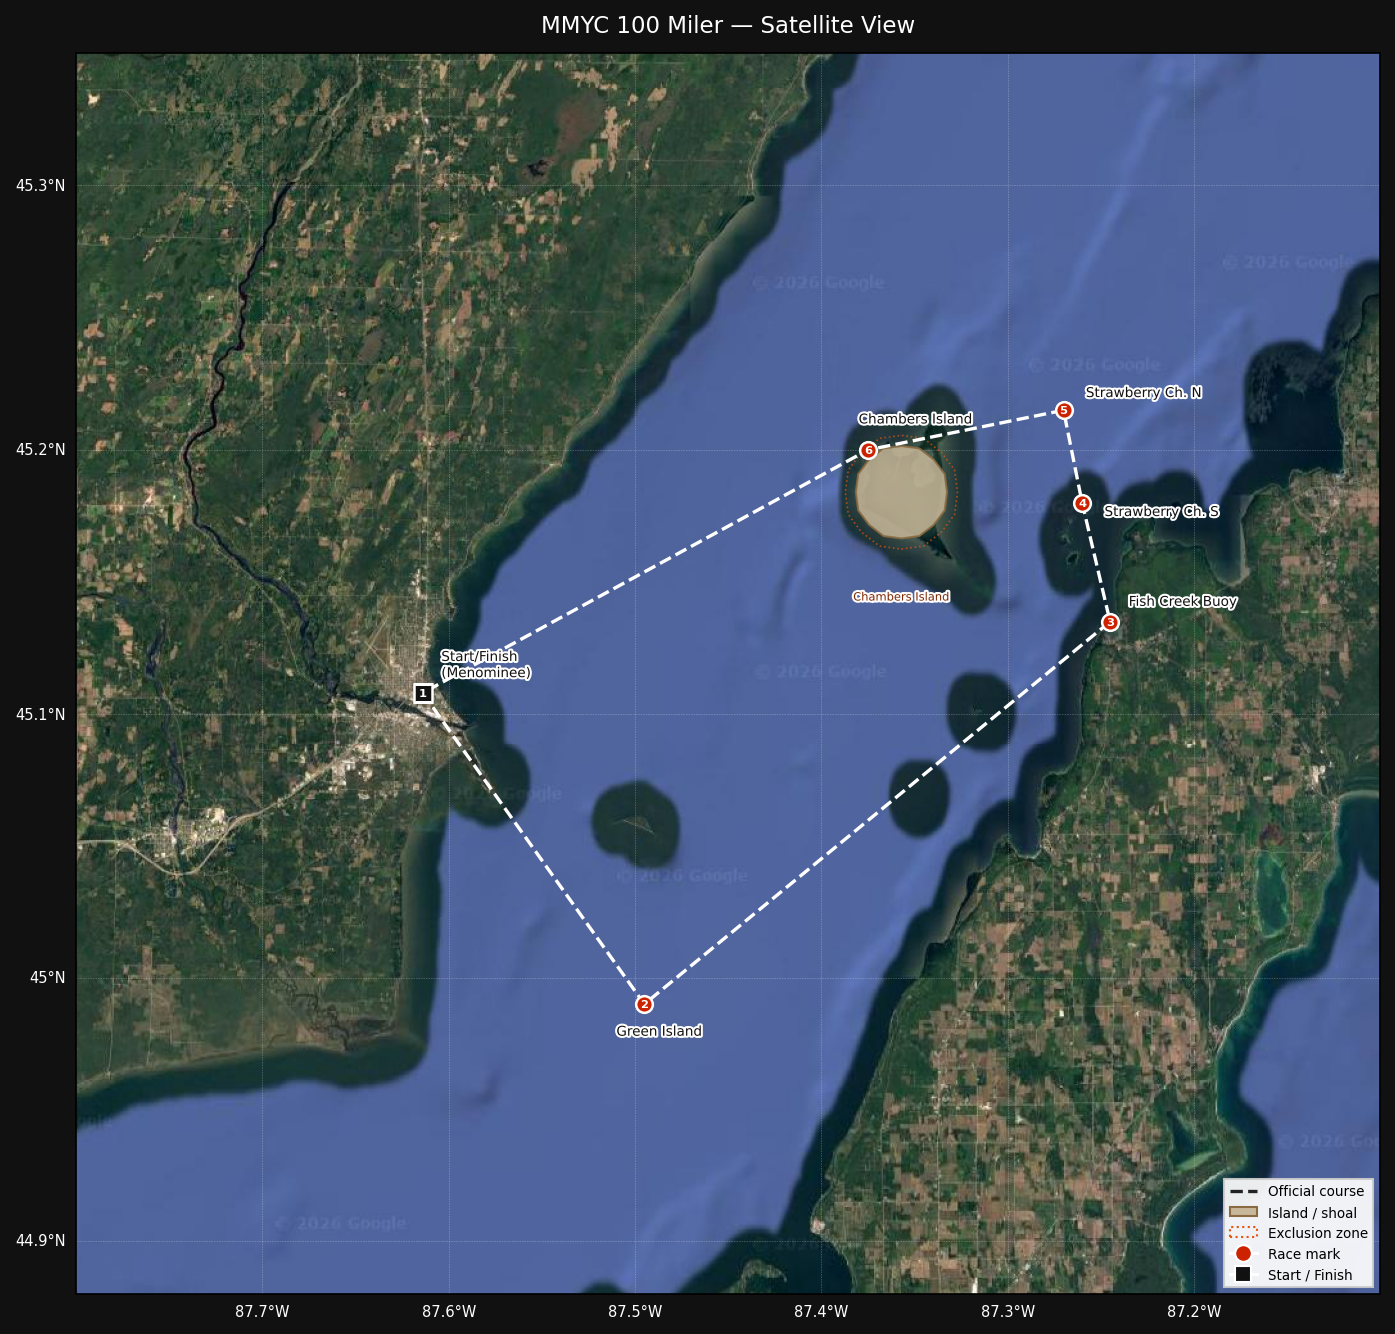

In [38]:
# Stamen Terrain gives a nice topographic feel for coastal sailing maps
tiler = cimgt.GoogleTiles(style='satellite')   # swap to 'terrain' or 'street' if preferred

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(1, 1, 1, projection=tiler.crs)

ax.set_extent(EXTENT, crs=PLATE)
ax.add_image(tiler, 11)   # zoom level 11 — increase for more detail, slower fetch

draw_obstacles(ax, OBSTACLES)
draw_course(ax, OFFICIAL, color='white', label='Official course')
draw_marks(ax, MARKS)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#ffffff88',
                  linestyle=':', x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'white'}
gl.ylabel_style = {'size': 7, 'color': 'white'}

add_legend(ax)
ax.set_title('MMYC 100 Miler — Satellite View', fontsize=11, pad=10, color='white')
fig.patch.set_facecolor('#111111')

plt.tight_layout()
# plt.savefig('mmyc_100_miler_satellite.png', dpi=200, bbox_inches='tight')
plt.show()

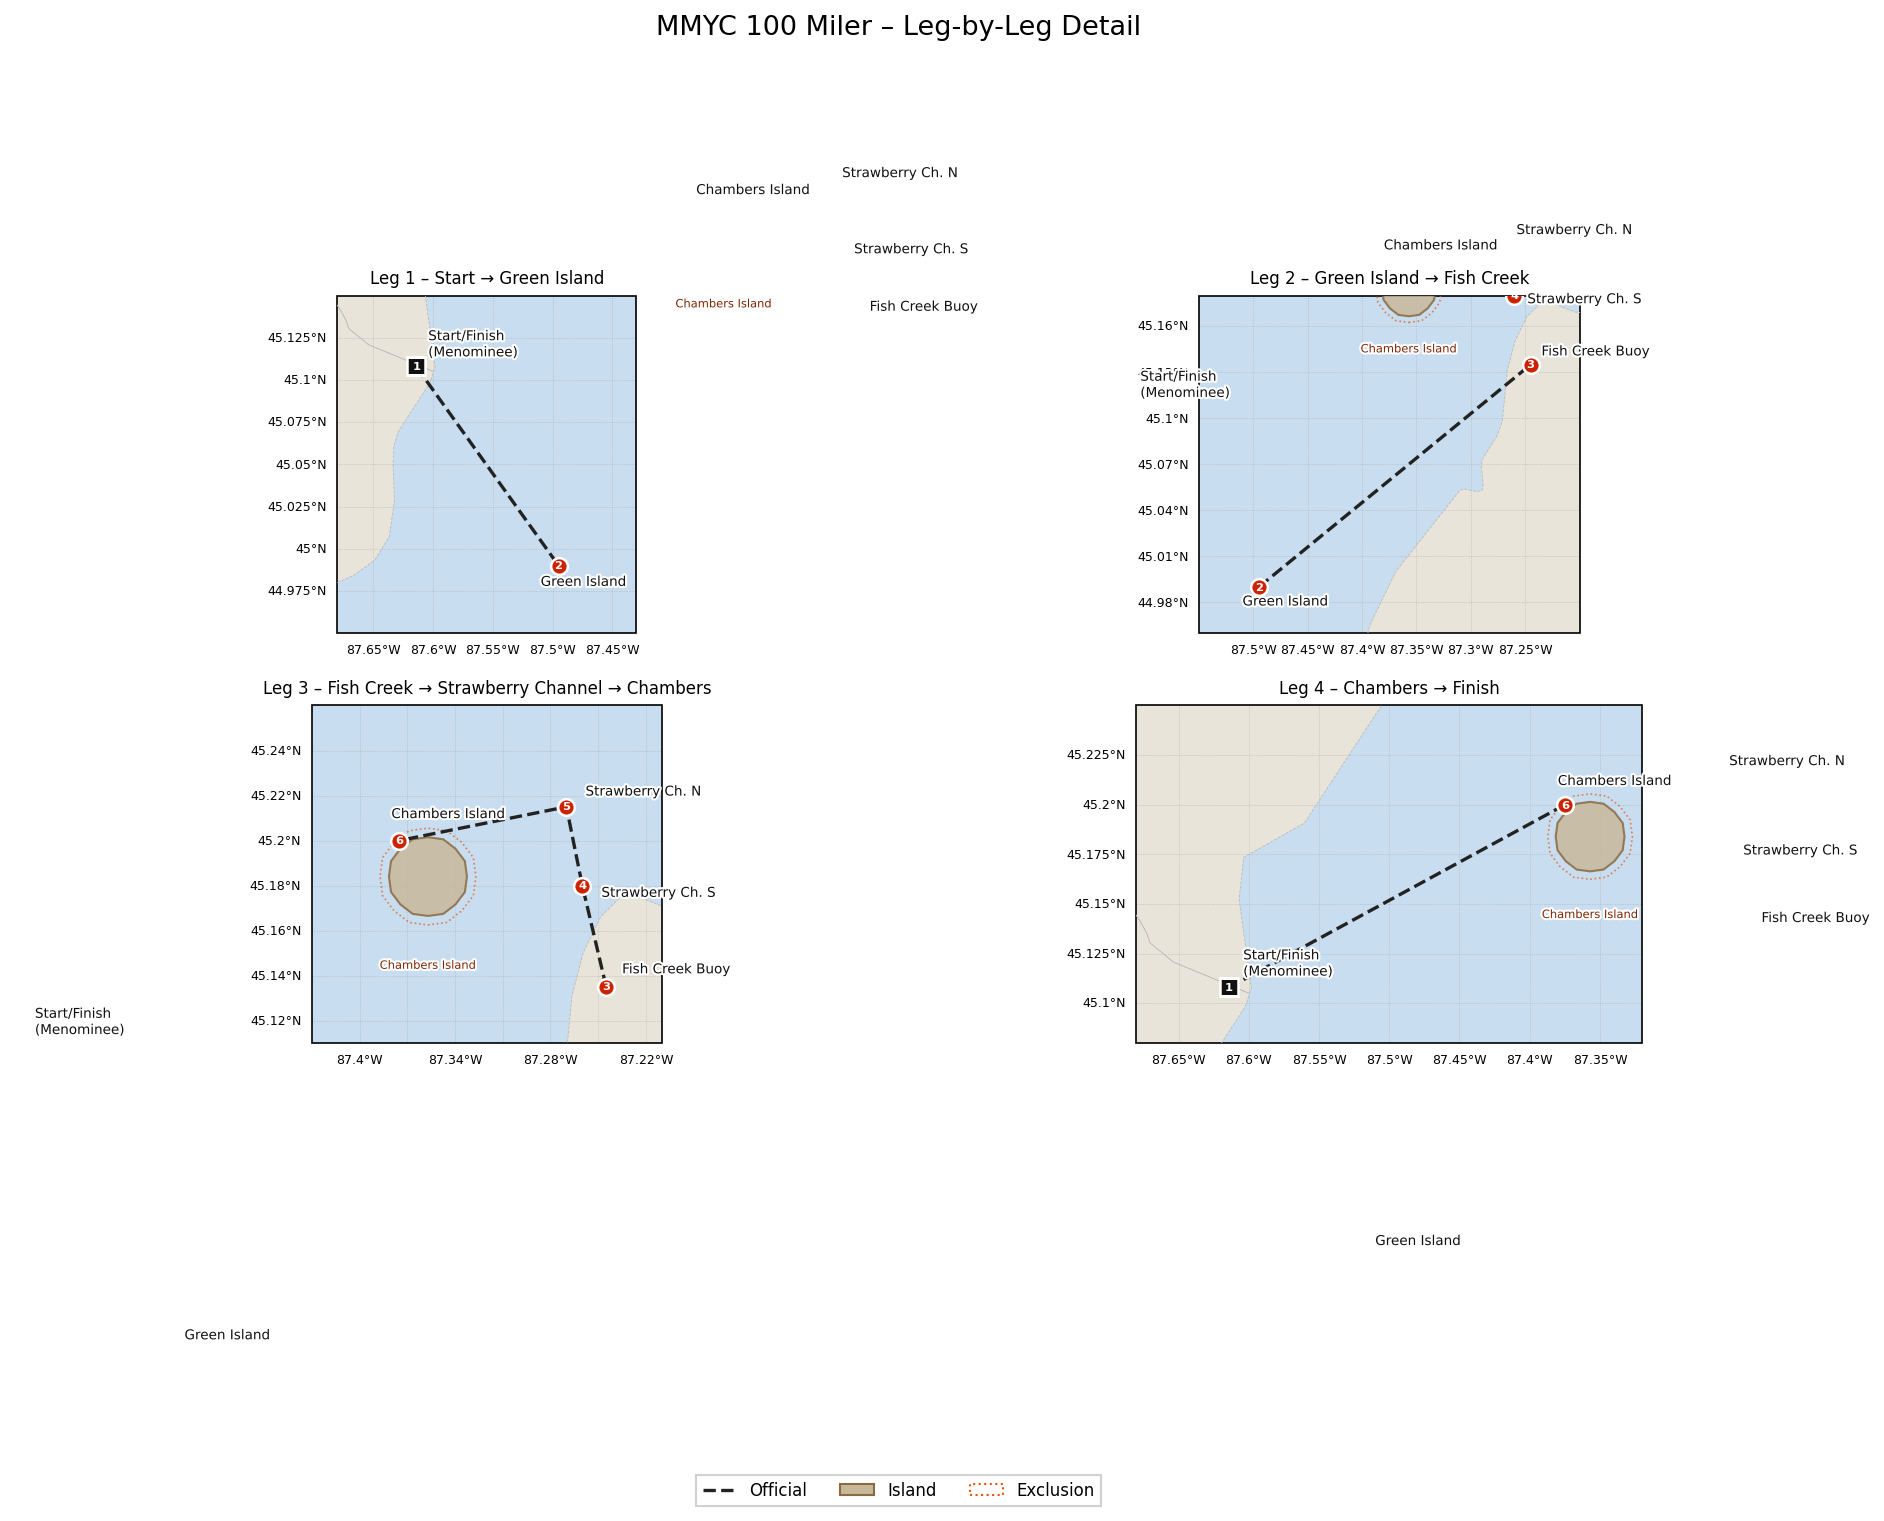

In [39]:
LEGS = [
    ("Leg 1 – Start → Green Island",
     [-87.68, -87.43, 44.95, 45.15],
     0, 2),
    ("Leg 2 – Green Island → Fish Creek",
     [-87.55, -87.20, 44.96, 45.18],
     1, 3),
    ("Leg 3 – Fish Creek → Strawberry Channel → Chambers",
     [-87.43, -87.21, 45.11, 45.26],
     2, 6),
    ("Leg 4 – Chambers → Finish",
     [-87.68, -87.32, 45.08, 45.25],
     5, 7),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          subplot_kw={'projection': ccrs.Mercator()})

for ax, (title, extent, i_start, i_end) in zip(axes.flat, LEGS):
    ax.set_extent(extent, crs=PLATE)
    add_basemap_features(ax)
    draw_obstacles(ax, OBSTACLES)

    # Slice official course to this leg
    leg_pts = OFFICIAL[i_start : min(i_end, len(OFFICIAL))]
    if leg_pts:
        draw_course(ax, leg_pts, label='Official')

    # Full routes (clipped to extent by matplotlib automatically)
    draw_marks(ax, MARKS)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#aaaaaa',
                      linestyle=':', x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 6}
    gl.ylabel_style = {'size': 6}
    ax.set_title(title, fontsize=8, pad=6)

# Shared legend on the figure
handles = [
    Line2D([0],[0], color='#222', lw=1.6, linestyle='--', label='Official'),
    mpatches.Patch(facecolor='#c8b89a', edgecolor='#8a6a40', label='Island'),
    mpatches.Patch(facecolor='none', edgecolor='#e6550d', linestyle=':', label='Exclusion'),
]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=8, framealpha=0.9, fancybox=False,
           bbox_to_anchor=(0.5, 0.01))

fig.suptitle('MMYC 100 Miler – Leg-by-Leg Detail', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('mmyc_100_miler_legs.png', dpi=200, bbox_inches='tight')

In [40]:
# ── Replace these with output from your OCP solver ──────────────────────────
my_optimal_route_waypoints = [
    (-87.614, 45.108),
    (-87.614, 45.108),
]

if len(my_optimal_route_waypoints) > 3:
    my_route = smooth_route(my_optimal_route_waypoints)

    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
    ax.set_extent(EXTENT, crs=PLATE)
    add_basemap_features(ax)
    draw_obstacles(ax, OBSTACLES)
    draw_course(ax, OFFICIAL)
    draw_route(ax, route_a, '#2171b5', 'Route A')
    draw_route(ax, route_b, '#d73027', 'Route B')
    draw_route(ax, my_route, '#2ca25f', 'My optimal route', lw=3.0)
    draw_marks(ax, MARKS)
    add_legend(ax, extra_handles=[
        Line2D([0],[0], color='#2ca25f', lw=3, label='My optimal route')
    ])
    ax.set_title('MMYC 100 Miler — With Optimal Control Solution', fontsize=11)
    plt.tight_layout()
    plt.savefig('mmyc_optimal.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Add your solver waypoints to my_optimal_route_waypoints above.")

Add your solver waypoints to my_optimal_route_waypoints above.


## Ethan Graphing

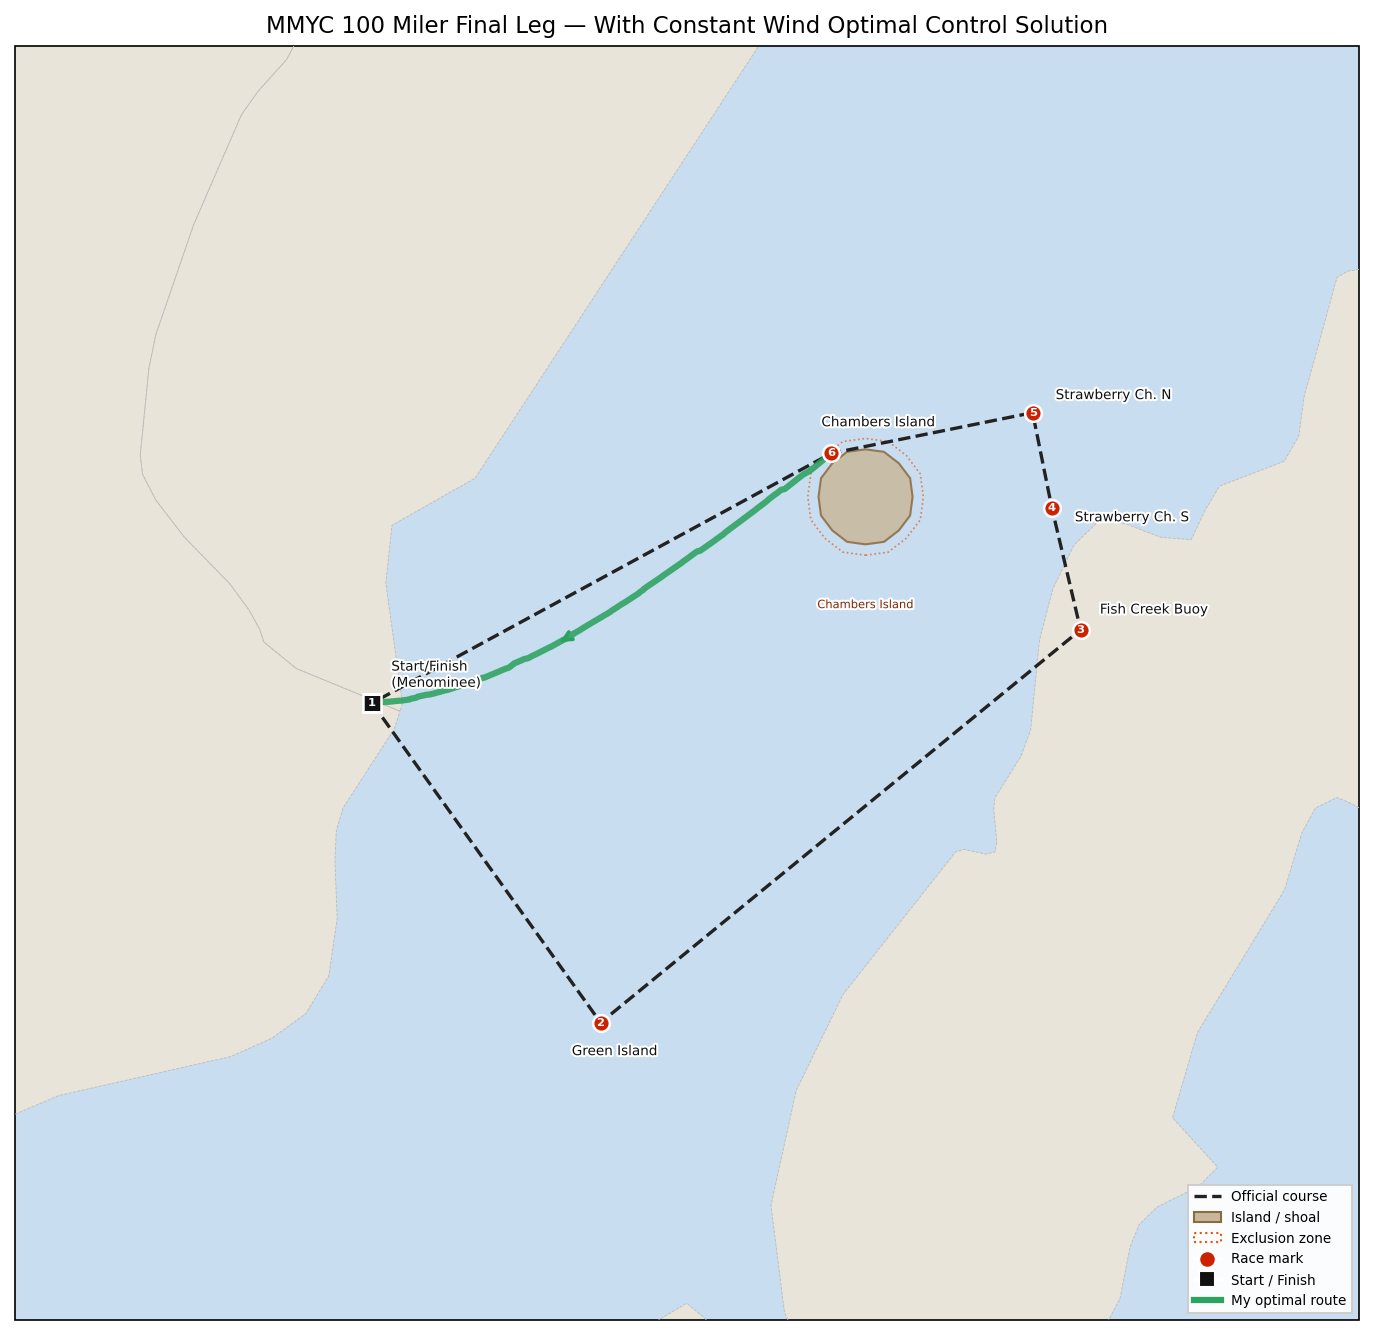

In [44]:
# Wind speed and angle
v = 10
phi = np.pi/4

# Building drift, change in drift, and the ode to solve
def w(x, y):
    x, y = np.atleast_1d(x), np.atleast_1d(y)
    return np.vstack((5*y, np.zeros_like(y)))

def dw(x, y):
    return np.array([
        [0, 2],
        [0, 0]
    ])

# Building the ODE
def ode(t, Y, p):
    T = p[0]

    x, y, l1, l2 = Y
    lnorm = np.sqrt(l1**2 + l2**2) + 1e-10

    theta = np.arctan2(l2, l1)  # optimal heading points along lambda
    u1 = v * np.cos(theta - phi) * np.cos(theta)
    u2 = v * np.cos(theta - phi) * np.sin(theta)

    w1, w2 = w(x, y)
  
    dx = T * (u1 + w1)
    dy = T * (u2 + w2)

    Dw = dw(x, y)
    dl1, dl2 = -T * (Dw.T @ np.array([l1, l2]))

    return np.array([dx, dy, dl1, dl2])

# The initial and final state
x0 = np.array([-87.375, 45.200])
xf = np.array([-87.614, 45.108])

# The boundary conditions
def bc(ya, yb, p):
    T = p[0]

    xa, ya_val, l1a, l2a = ya
    xb, yb_val, l1b, l2b = yb

    lam_norm = np.sqrt(l1b**2 + l2b**2) + 1e-10
    
    theta_b = np.arctan2(l2b, l1b)
    u1b = v * np.cos(theta_b - phi) * np.cos(theta_b)
    u2b = v * np.cos(theta_b - phi) * np.sin(theta_b)
    
    wb = w(xb, yb_val).flatten()
    
    Hf = l1b * (u1b + wb[0]) + l2b * (u2b + wb[1]) - 1.0

    return np.array([
        xa - x0[0],
        ya_val - x0[1],
        xb - xf[0],
        yb_val - xf[1],
        Hf
    ])

# Computing the optimal route
t = np.linspace(0, 1, 100)

# Initial guesses
Y_guess = np.zeros((4, t.size))
p_guess = np.array([2.0])
Y_guess[0] = np.linspace(x0[0], xf[0], t.size)
Y_guess[1] = np.linspace(x0[1], xf[1], t.size)
Y_guess[2] = 1.0
Y_guess[3] = 1.0

# Solving the ode
sol = solve_bvp(ode, bc, t, Y_guess, p=p_guess)

# Plotting the optimal route
my_optimal_route_waypoints = np.zeros([len(sol.y[0]), 2])
my_optimal_route_waypoints[:, 0] = sol.y[0]
my_optimal_route_waypoints[:, 1] = sol.y[1]

if len(my_optimal_route_waypoints) > 3:
    my_route = smooth_route(my_optimal_route_waypoints)

    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
    ax.set_extent(EXTENT, crs=PLATE)
    add_basemap_features(ax)
    draw_obstacles(ax, OBSTACLES)
    draw_course(ax, OFFICIAL)
    # draw_route(ax, route_a, '#2171b5', 'Route A')
    # draw_route(ax, route_b, '#d73027', 'Route B')
    draw_route(ax, my_route, '#2ca25f', 'My optimal route', lw=3.0)
    draw_marks(ax, MARKS)
    add_legend(ax, extra_handles=[
        Line2D([0],[0], color='#2ca25f', lw=3, label='My optimal route')
    ])
    ax.set_title('MMYC 100 Miler Final Leg — With Constant Wind Optimal Control Solution', fontsize=11)
    plt.tight_layout()
    plt.savefig('mmyc_optimal.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Add your solver waypoints to my_optimal_route_waypoints above.")